# CMSDAS 2026 Hefei — Short Exercise: Machine Learning
# Session #1: Basics of BDT and DNN

Course Indico link: https://indico.cern.ch/event/1639697/timetable/?view=standard#263-machine-learning

This notebook is available on the Course [GitLab page](https://gitlab.cern.ch/das-hefei2026/exercise/-/tree/master/Short_exercise/Machine_Learning).

Before starting this notebook, go through the `sesh0_intro.pdf` introductory slides for a quick understanding of the concepts.

## Background setup

The discovery of the Higgs boson in 2012 completed the last missing piece of the Standard Model and was a milestone in particle physics experiments. One of the main goals of the upcoming High-Luminosity LHC experiments is to study the self-coupling property of the Higgs boson. In the Standard Model, after electroweak symmetry breaking, the Lagrangian includes terms where Higgs bosons couple to themselves. This leads to physical processes where three or four Higgs bosons interact directly. A typical example is shown in the Feynman diagram below, which illustrates one way that two Higgs bosons can be produced together.

<img src="figures/DihiggsFD.jpg" alt="Drawing" width=300/>

In this process, because of the Higgs self-coupling, two Higgs bosons are produced in the final state. If we can measure the cross section of this process, we can set limits on the self-coupling modifier $\kappa_\lambda$. Here, we focus on a special decay mode: one Higgs decays to $b\bar{b}$ (the most common decay), and the other decays to $W^+W^-$. In this example, we will use reconstructed event information to distinguish the double Higgs signal process $HH\to b\bar{b}W^+W^-$ from its main background process $t\bar{t}\to b\bar{b}W^+W^-$. The signal and background have the following features:
 - Both processes have exactly the same final state particles: two b quarks form two b-jets; the two W bosons decay leptonically, producing two leptons (electrons or muons) and invisible neutrinos.
 - However, the kinematics of the final state particles are slightly different: in $HH$ and $t\bar{t}$, the particles are produced back-to-back (due to relativistic effects), but in $HH$ the two b-jets and two W bosons tend to be close to each other, while in $t\bar{t}$ each b-jet and W boson pair tends to be close.
 - Experimentally, we can measure the final state information for both signal and background, i.e. the two b-jets and two leptons (their four-momenta, jet properties, etc.).

So, can we use machine learning techniques to distinguish these two processes using the reconstructed event information?

<img src="figures/SigBkgFS.png" alt="Drawing" width=700/>

## Inspecting our dataset

Our dataset contains examples of both the signal and background physics processes described above.

In the ROOT file, jets and leptons are stored as variable-length vectors per event (`jet_*`, `lep_*`). We select the two leading b-tagged jets by $p_\mathrm{T}$ and the two leading leptons by $p_\mathrm{T}$, then build flat columns `bjet1_*`, `bjet2_*`, `lep1_*`, `lep2_*`, plus `met_pt` / `met_phi`. The table below shows this flattened `pandas` view.


In [ ]:
import os
import uproot
import awkward as ak
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Load with Awkward: jets and leptons are per-event variable-length vectors (jagged arrays).
SIG_PATH = "/eos/user/c/coli/cms-repo/cmsdas/data/train_and_test_sig_hhbbww_1M.root:tree"
BKG_PATH = "/eos/user/c/coli/cms-repo/cmsdas/data/train_and_test_bkg_ttbar_1M.root:tree"

ak_sig = uproot.concatenate(SIG_PATH, library="ak")
ak_bkg = uproot.concatenate(BKG_PATH, library="ak")

def _round2(x):
    if isinstance(x, float):
        return round(x, 2)
    if isinstance(x, list):
        return [_round2(v) for v in x]
    return x

print("=== Inspect branches: print two events (signal file) ===\n")
for name in ak_sig.fields:
    arr = ak_sig[name]
    print(name)
    print(" ", arr.type)
    print(" ", _round2(ak.to_list(arr[1:3])))
    print()

=== Inspect branches: print two events (signal file) ===

jet_pt
  1000000 * var * float32
  [[699.22, 413.56, 234.12, 148.36, 103.56, 64.93, 44.53, 34.81, 34.17, 33.04, 20.44], [435.95, 285.27, 223.49, 18.79]]

jet_eta
  1000000 * var * float32
  [[0.0, -0.13, -1.51, -0.5, -1.07, 0.07, 1.88, 2.52, -1.45, -0.45, -2.16], [-0.16, 0.52, 0.93, 0.51]]

jet_phi
  1000000 * var * float32
  [[-0.65, 2.62, -3.06, 0.88, 0.72, 0.79, -3.13, -2.76, 1.67, -0.71, -3.0], [2.22, -1.33, -0.47, -2.65]]

jet_energy
  1000000 * var * float32
  [[706.05, 417.56, 558.76, 168.47, 169.21, 65.74, 149.02, 218.53, 77.43, 36.62, 89.48], [444.12, 325.26, 329.26, 21.68]]

jet_mass
  1000000 * var * float32
  [[97.98, 23.49, 24.38, 22.38, 14.46, 9.34, 5.39, 2.44, 7.68, 4.04, 3.93], [48.28, 21.36, 41.28, 3.96]]

jet_is_btag
  1000000 * var * int32
  [[0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0], [0, 1, 0, 1]]

lep_pt
  1000000 * var * float32
  [[257.71, 166.02], [146.31, 81.17]]

lep_eta
  1000000 * var * float32
  [[-0.08, -0.

Now convert the variable-length vector branches into a flat `pandas` DataFrame.

In [ ]:
def vector_branches_to_flat_df(events):
    """Two leading b-jets by pT among b-tagged jets; two leading leptons by pT."""
    is_b = events["jet_is_btag"] == 1
    bjet_pt = events["jet_pt"][is_b]
    bjet_eta = events["jet_eta"][is_b]
    bjet_phi = events["jet_phi"][is_b]
    bjet_energy = events["jet_energy"][is_b]
    bjet_mass = events["jet_mass"][is_b]

    order_j = ak.argsort(bjet_pt, axis=-1, ascending=False)
    b1_pt = bjet_pt[order_j][:, 0]
    b2_pt = bjet_pt[order_j][:, 1]
    b1_eta = bjet_eta[order_j][:, 0]
    b2_eta = bjet_eta[order_j][:, 1]
    b1_phi = bjet_phi[order_j][:, 0]
    b2_phi = bjet_phi[order_j][:, 1]
    b1_energy = bjet_energy[order_j][:, 0]
    b2_energy = bjet_energy[order_j][:, 1]
    b1_mass = bjet_mass[order_j][:, 0]
    b2_mass = bjet_mass[order_j][:, 1]

    lep_pt = events["lep_pt"]
    order_l = ak.argsort(lep_pt, axis=-1, ascending=False)
    l1_pt = lep_pt[order_l][:, 0]
    l2_pt = lep_pt[order_l][:, 1]
    l1_eta = events["lep_eta"][order_l][:, 0]
    l2_eta = events["lep_eta"][order_l][:, 1]
    l1_phi = events["lep_phi"][order_l][:, 0]
    l2_phi = events["lep_phi"][order_l][:, 1]
    l1_energy = events["lep_energy"][order_l][:, 0]
    l2_energy = events["lep_energy"][order_l][:, 1]
    l1_iso = events["lep_iso"][order_l][:, 0]
    l2_iso = events["lep_iso"][order_l][:, 1]
    l1_pid = events["lep_pid"][order_l][:, 0]
    l2_pid = events["lep_pid"][order_l][:, 1]

    l1_type = ak.where(np.abs(l1_pid) == 11, 0, 1)  # 0 = e, 1 = mu (|PDG|)
    l2_type = ak.where(np.abs(l2_pid) == 11, 0, 1)

    def to_np(a):
        return np.asarray(ak.to_numpy(a))

    d = {
        "bjet1_pt": to_np(b1_pt),
        "bjet1_eta": to_np(b1_eta),
        "bjet1_phi": to_np(b1_phi),
        "bjet1_energy": to_np(b1_energy),
        "bjet1_mass": to_np(b1_mass),
        "bjet2_pt": to_np(b2_pt),
        "bjet2_eta": to_np(b2_eta),
        "bjet2_phi": to_np(b2_phi),
        "bjet2_energy": to_np(b2_energy),
        "bjet2_mass": to_np(b2_mass),
        "lep1_pt": to_np(l1_pt),
        "lep1_eta": to_np(l1_eta),
        "lep1_phi": to_np(l1_phi),
        "lep1_energy": to_np(l1_energy),
        "lep1_type": to_np(l1_type),
        "lep1_iso": to_np(l1_iso),
        "lep2_pt": to_np(l2_pt),
        "lep2_eta": to_np(l2_eta),
        "lep2_phi": to_np(l2_phi),
        "lep2_energy": to_np(l2_energy),
        "lep2_type": to_np(l2_type),
        "lep2_iso": to_np(l2_iso),
        "met_pt": to_np(events["met_pt"]),
        "met_phi": to_np(events["met_phi"]),
    }
    return pd.DataFrame(d)

dihiggs = vector_branches_to_flat_df(ak_sig)
ttbar = vector_branches_to_flat_df(ak_bkg)

# add a column to indicate the signal or background
dihiggs["is_sig"] = True
ttbar["is_sig"] = False
dihiggs["is_bkg"] = False
ttbar["is_bkg"] = True

# concatenate the two dataframes
df_raw = pd.concat([dihiggs, ttbar], axis=0, ignore_index=True)

# let's print the first few rows
df_raw

,bjet1_pt,bjet1_eta,bjet1_phi,bjet1_energy,bjet1_mass,bjet2_pt,bjet2_eta,bjet2_phi,bjet2_energy,bjet2_mass,...,lep2_pt,lep2_eta,lep2_phi,lep2_energy,lep2_type,lep2_iso,met_pt,met_phi,is_sig,is_bkg
0,444.501923,0.105127,1.735936,449.618042,48.813301,123.654938,-0.162405,-1.191188,126.383156,16.592310,...,71.062408,-0.833013,-1.917636,97.176979,0,0.000000,293.322327,-1.587221,True,False
1,103.557709,-1.069062,0.718402,169.209290,14.455474,64.933945,0.066322,0.793697,65.743813,9.341219,...,166.020111,-0.196509,2.622604,169.235947,1,0.003754,90.935844,-3.005666,True,False
2,285.272797,0.518930,-1.331809,325.255188,21.363674,18.789450,0.512466,-2.649146,21.675430,3.957021,...,81.168381,0.933178,-0.714921,119.150223,1,0.000000,44.661823,1.004843,True,False
3,77.749916,0.975322,-2.195574,118.559029,13.777265,46.196110,-0.497366,-1.271545,52.320866,5.521458,...,120.987740,0.723403,-1.443911,154.049744,1,0.000000,38.473652,1.925897,True,False
4,119.080132,1.321448,-0.090223,239.214539,7.753564,70.431656,1.071832,1.101663,115.291039,9.329151,...,52.678146,-0.059516,0.079800,52.771473,0,0.000000,164.234344,-0.158505,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1999995,98.372452,-2.000969,-0.145557,370.840759,17.184757,58.718704,-1.652765,0.723505,159.365280,11.907846,...,26.475773,-0.494083,1.763925,29.773655,1,0.026304,111.218956,0.601672,False,True
1999996,125.426781,-2.462708,2.985823,741.509705,13.725430,30.843245,-0.274412,0.309911,32.356407,4.709532,...,59.586742,-1.220256,-2.827555,109.735207,0,0.000000,48.477661,0.037827,False,True
1999997,47.859745,0.247440,1.090933,49.399300,2.570440,38.596741,0.396086,-2.540947,42.143250,6.336686,...,56.162819,1.176300,0.187843,99.710739,1,0.000000,67.511238,1.244732,False,True
1999998,37.608448,-0.084510,-0.838220,38.531933,7.758161,37.403996,2.156487,0.865421,163.986023,8.543921,...,62.089382,-0.011076,-0.180065,62.093189,1,0.093152,70.788620,2.244687,False,True


Let's use what we have learned in the previous session to plot histograms for each feature and examine their basic distributions.

> We can see that if we only look at the kinematic information of the final-state leptons and jets, it is difficult to distinguish between the two processes.

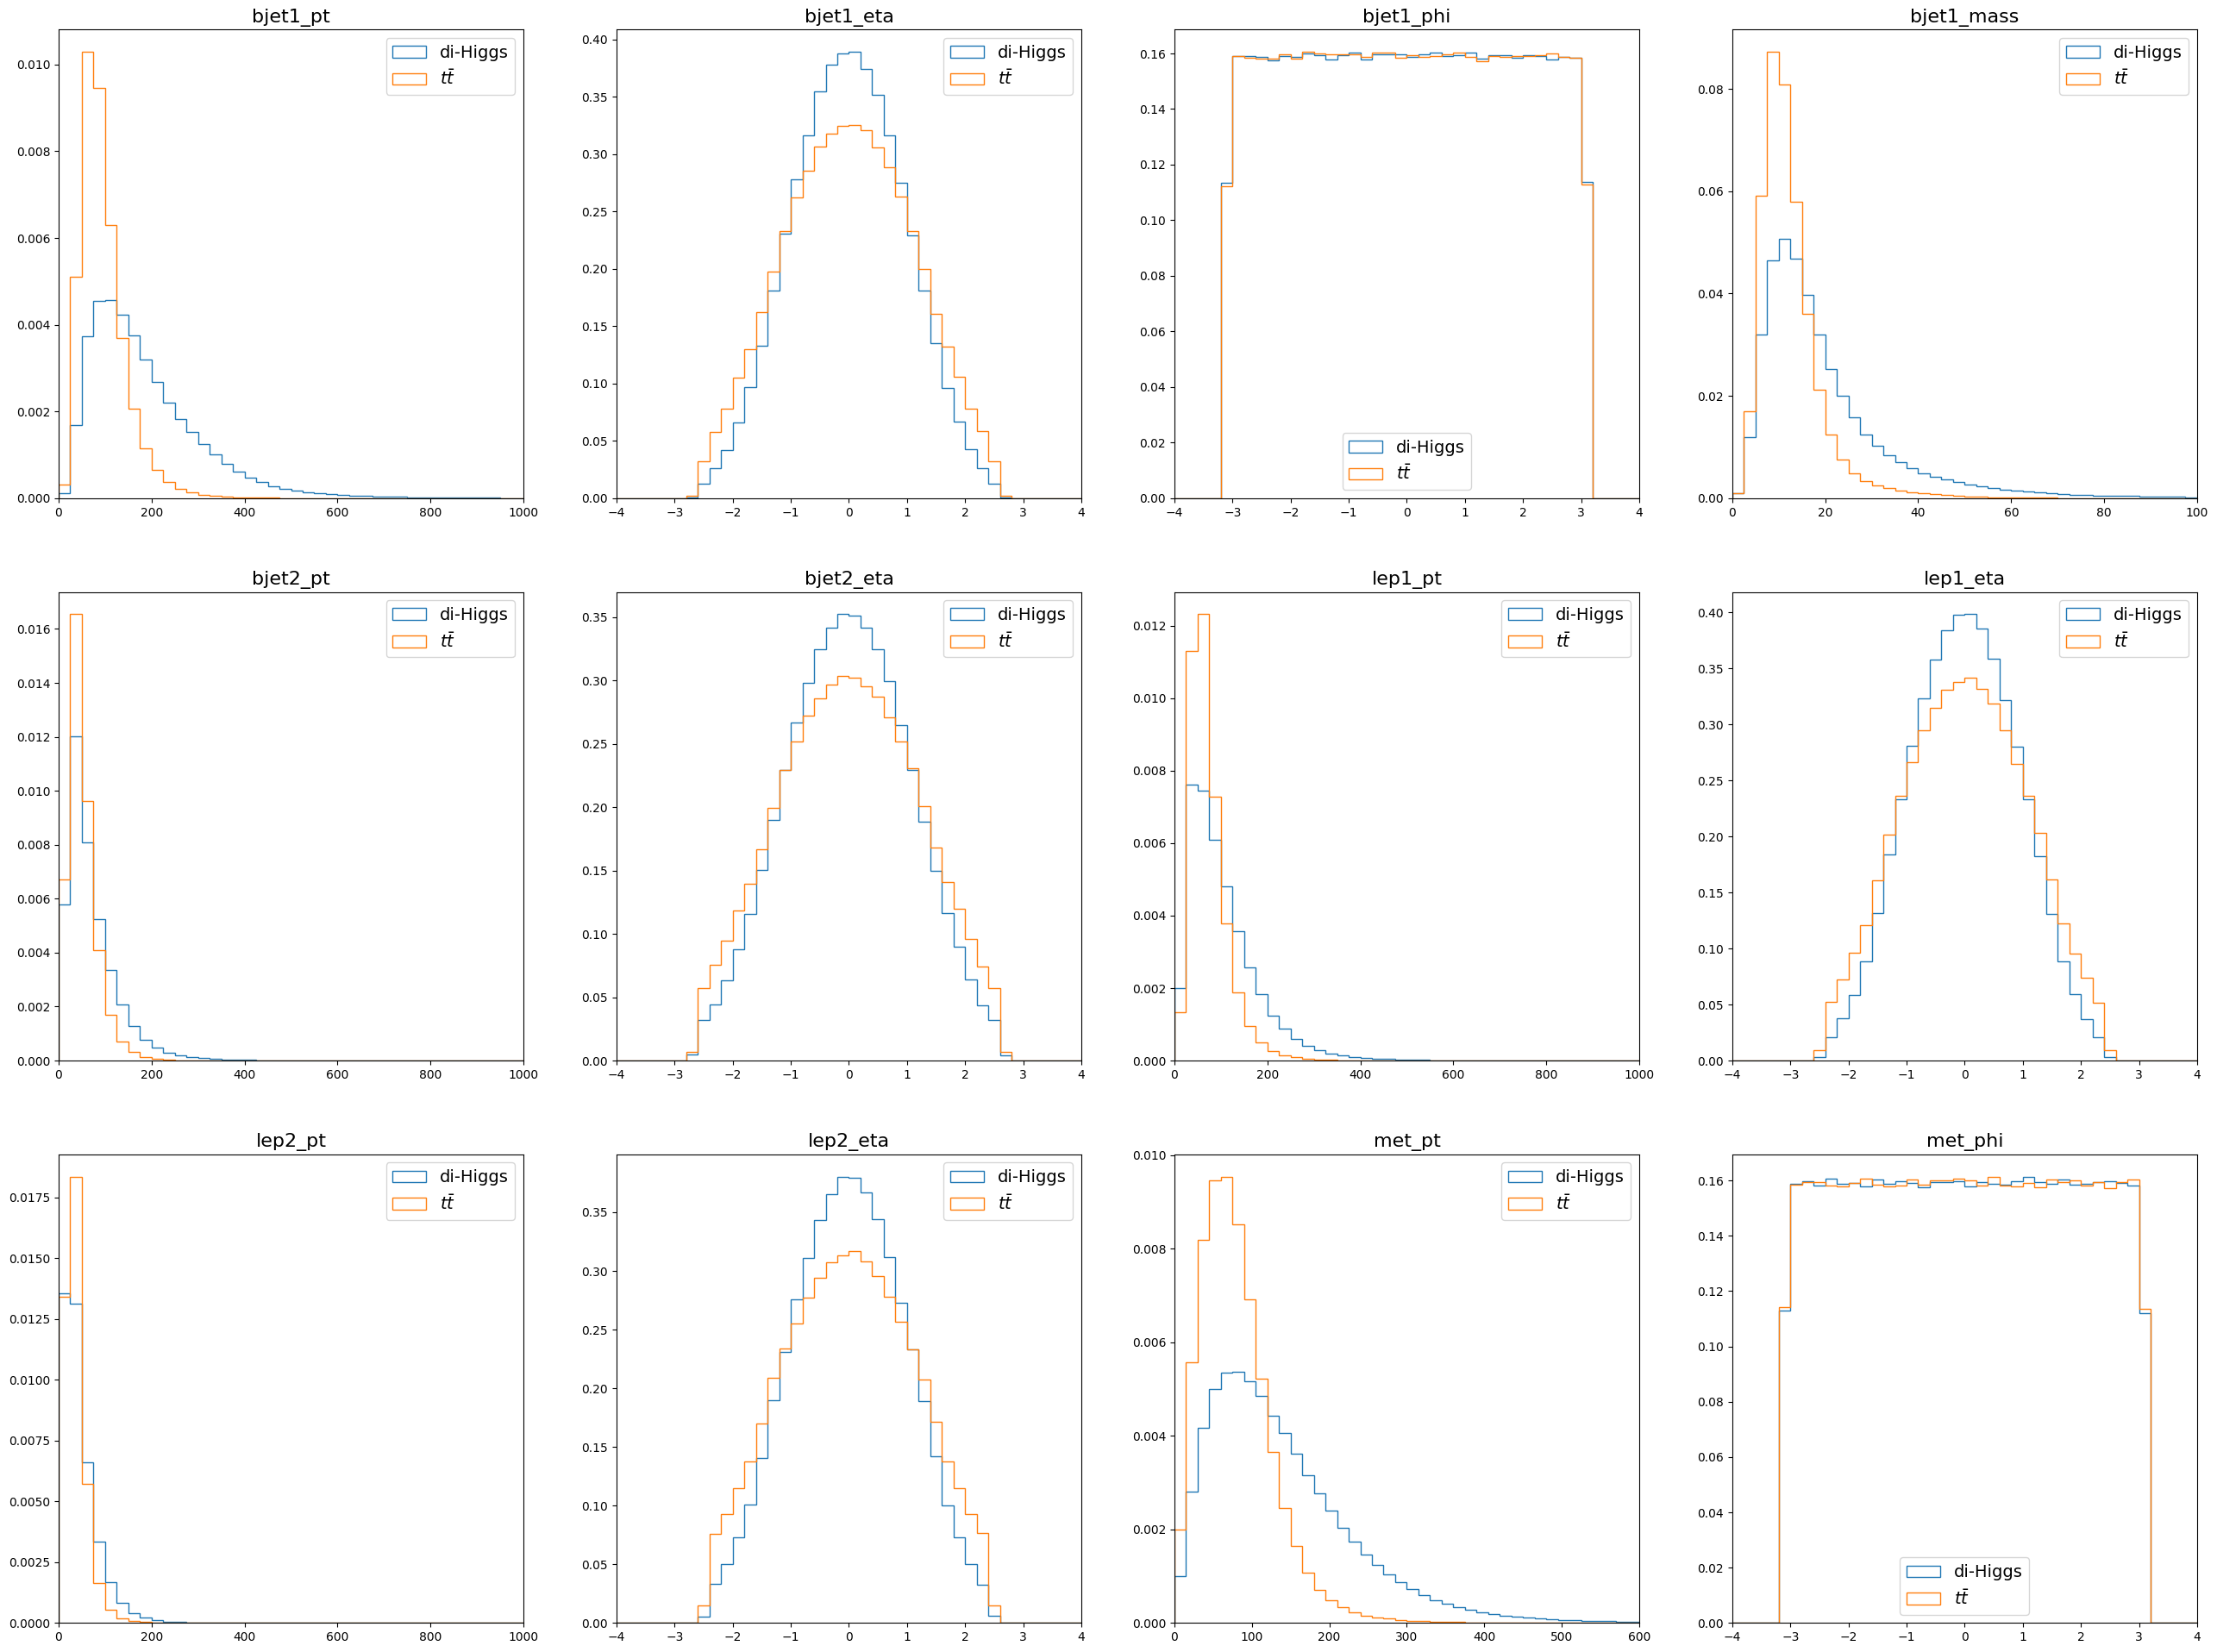

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define a list of tuples for plotting: (variable name, number of bins, x-axis min, x-axis max)
plotinfo = [ # varname, nbin, xmin, xmax
    ('bjet1_pt', 40, 0, 1000),
    ('bjet1_eta', 40, -4, 4),
    ('bjet1_phi', 40, -4, 4),
    ('bjet1_mass', 40, 0, 100),
    ('bjet2_pt', 40, 0, 1000),
    ('bjet2_eta', 40, -4, 4),
    ('lep1_pt', 40, 0, 1000),
    ('lep1_eta', 40, -4, 4),
    ('lep2_pt', 40, 0, 1000),
    ('lep2_eta', 40, -4, 4),
    ('met_pt', 40, 0, 600),
    ('met_phi', 40, -4, 4),
]

plt.figure(figsize=(32, 24))  # Set the overall figure size for all subplots

for i, (varname, nbin, xmin, xmax) in enumerate(plotinfo):
    plt.subplot(3, 4, i+1)  # Arrange subplots in a 3x4 grid
    bins = np.linspace(xmin, xmax, nbin+1)  # Define bin edges for the histogram

    # Plot signal and background distributions for the current variable
    plt.hist(dihiggs[varname], histtype="step", bins=bins, label="di-Higgs", density=True)
    plt.hist(ttbar[varname], histtype="step", bins=bins, label="$t\\bar{t}$", density=True)

    plt.legend(fontsize=14)  # Add legend with specified font size
    plt.xlim(xmin, xmax)     # Set x-axis limits
    plt.title(varname, fontsize=16)  # Set subplot title as variable name

Notice that when looking at individual physics objects, it is hard to distinguish between the two processes.

But what if we consider the correlations between multiple physics objects? Will the separation improve?

Text(0.5, 1.0, '$\\Delta\\eta_{l_1,l_2}$')

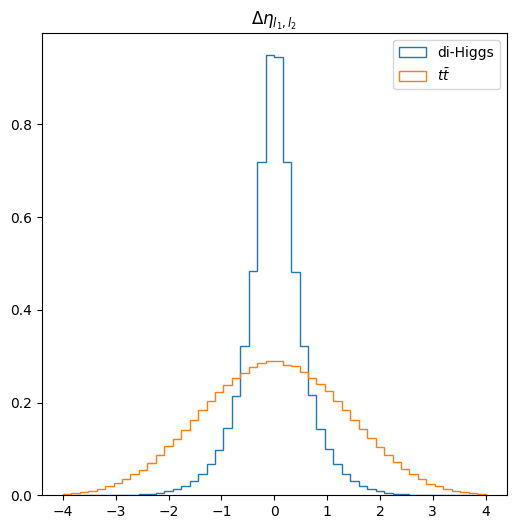

In [ ]:
# Making a distribution plot for "lep1_eta - lep2_eta"

plt.figure(figsize=(6, 6))
plt.hist(dihiggs['lep1_eta'] - dihiggs['lep2_eta'], histtype="step", bins=np.linspace(-4,4,50+1), label="di-Higgs", density=True)
plt.hist(ttbar['lep1_eta'] - ttbar['lep2_eta'], histtype="step", bins=np.linspace(-4,4,50+1), label=r"$t\bar{t}$", density=True)
plt.legend()
plt.title(r"$\Delta\eta_{l_1,l_2}$")

We can see that in the di-Higgs process, both W bosons come from the Higgs, so the leptons from their decays tend to be closer together. In contrast, in the ttbar process, the two W bosons come from two separate top quarks, so the leptons are more likely to be back-to-back.

This shows that if we use machine learning methods and include multiple kinematic variables in our analysis, we can take advantage of the correlations between these variables to more efficiently separate signal from background.


## Prepare the dataset

In general, a model learns better if the input features are on similar scales. If the input features have very different ranges (for example, some are always between 0 and 1, while others like jet pT can be in the thousands), the optimization will be harder.

To help the model train well, we standardize each feature: subtract the mean and divide by the standard deviation.

> Note: For variables with long tails, like jet $p_\mathrm{T}$, besides standardization, it is common to apply a log transformation, such as $\log(|x|)$ or $\log(|x|+1)$, to make the distribution more Gaussian-like. This can also help improve the model performance.

In [ ]:
# Initialize the StandardScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

input_columns = ['bjet1_pt', 'bjet1_eta', 'bjet1_phi', 'bjet1_energy', 'bjet1_mass',
       'bjet2_pt', 'bjet2_eta', 'bjet2_phi', 'bjet2_energy', 'bjet2_mass',
       'lep1_pt', 'lep1_eta', 'lep1_phi', 'lep1_energy',
       'lep2_pt', 'lep2_eta', 'lep2_phi', 'lep2_energy',
       'met_pt', 'met_phi']

# Fit and transform the DataFrame
df_trans = pd.DataFrame(scaler.fit_transform(df_raw[input_columns]), columns=[c + '_trans' for c in input_columns], index=df_raw.index)
df = pd.concat([df_trans, df_raw], axis=1)
df

,bjet1_pt_trans,bjet1_eta_trans,bjet1_phi_trans,bjet1_energy_trans,bjet1_mass_trans,bjet2_pt_trans,bjet2_eta_trans,bjet2_phi_trans,bjet2_energy_trans,bjet2_mass_trans,...,lep2_pt,lep2_eta,lep2_phi,lep2_energy,lep2_type,lep2_iso,met_pt,met_phi,is_sig,is_bkg
0,2.919366,0.100430,0.957457,1.164611,2.560886,1.278334,-0.145437,-0.656501,0.197858,1.218395,...,71.062408,-0.833013,-1.917636,97.176979,0,0.000000,293.322327,-1.587221,True,False
1,-0.361785,-1.032578,0.396169,-0.288796,-0.149153,0.056812,0.058525,0.437591,-0.422148,0.109671,...,166.020111,-0.196509,2.622604,169.235947,1,0.003754,90.935844,-3.005666,True,False
2,1.386990,0.499720,-0.734761,0.520017,0.395744,-0.903092,0.456362,-1.460144,-0.872724,-0.713597,...,81.168381,0.933178,-0.714921,119.150223,1,0.000000,44.661823,1.004843,True,False
3,-0.610152,0.940106,-1.211228,-0.551325,-0.202648,-0.332975,-0.444129,-0.700794,-0.559391,-0.474388,...,120.987740,0.723403,-1.443911,154.049744,1,0.000000,38.473652,1.925897,True,False
4,-0.212402,1.274093,-0.049882,0.074054,-0.677779,0.171176,0.955161,0.607345,0.084446,0.107826,...,52.678146,-0.059516,0.079800,52.771473,0,0.000000,164.234344,-0.158505,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1999995,-0.411686,-1.931802,-0.080405,0.756295,0.066124,-0.072478,-1.474425,0.398900,0.535083,0.502120,...,26.475773,-0.494083,1.763925,29.773655,1,0.026304,111.218956,0.601672,False,True
1999996,-0.151323,-2.377347,1.646916,2.677535,-0.206737,-0.652347,-0.245316,0.170922,-0.763517,-0.598535,...,59.586742,-1.220256,-2.827555,109.735207,0,0.000000,48.477661,0.037827,False,True
1999997,-0.897806,0.237752,0.601663,-0.909791,-1.086608,-0.491058,0.352583,-1.400503,-0.663451,-0.349736,...,56.162819,1.176300,0.187843,99.710739,1,0.000000,67.511238,1.244732,False,True
1999998,-0.996462,-0.082556,-0.462490,-0.966119,-0.677416,-0.515870,1.922373,0.477126,0.582327,-0.012239,...,62.089382,-0.011076,-0.180065,62.093189,1,0.093152,70.788620,2.244687,False,True


In [ ]:
# Define the features and labels
X = df[['bjet1_pt_trans', 'bjet1_eta_trans', 'bjet1_phi_trans', 'bjet1_energy_trans', 'bjet1_mass_trans',
       'bjet2_pt_trans', 'bjet2_eta_trans', 'bjet2_phi_trans', 'bjet2_energy_trans', 'bjet2_mass_trans',
       'lep1_pt_trans', 'lep1_eta_trans', 'lep1_phi_trans', 'lep1_energy_trans', 'lep1_type', 'lep1_iso',
       'lep2_pt_trans', 'lep2_eta_trans', 'lep2_phi_trans', 'lep2_energy_trans', 'lep2_type', 'lep2_iso',
       'met_pt_trans', 'met_phi_trans']]
y = df[['is_sig', 'is_bkg']] 

Let's first split the dataset into three parts: training, validation, and testing samples (the validation set is not used in the following training steps). We use the function provided by scikit-learn to divide the data into these three sets with a ratio of 80/10/10%:

In [ ]:
from sklearn.model_selection import train_test_split

# First, split the original dataset into a training set (80%) and a temporary validation/test set (20%)
X_train, X_valtest, y_train, y_valtest = train_test_split(X, y, test_size=0.2)

# The final split ratio is: training/validation/test = 80/10/10
X_val, X_test, y_val, y_test = train_test_split(X_valtest, y_valtest, test_size=0.5)

## A simple test with a linear model

To show the power of machine learning algorithms, let's first try to solve this problem using a basic linear model.

Logistic Regression is a classic machine learning method for binary classification (0 or 1), and it was proposed as early as the 19th century. In simple terms, for each data point and its label $(\mathbf{x}, y)$, logistic regression applies a linear transformation to $\mathbf{x}$, and then uses the sigmoid function to estimate the probability that $y$ is 1:

$$P(Y=1|\mathbf{x}) = \frac{1}{1 + e^{\mathbf{w}\cdot\mathbf{x} + \mathbf{b}}}$$


In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize a logistic regression classifier with no regularization (penalty=None)
# set random seed for reproducibility, and increase max iterations for convergence
clf = LogisticRegression(random_state=0, penalty=None, max_iter=2000).fit(X_train, y_train['is_sig'])

# Evaluate the classifier on the validation set and return the accuracy score
clf.score(X_val, y_val['is_sig'])

0.79332

In [ ]:
# Now we evaluate the performance of the linear model on the test set
test_score = clf.predict_proba(X_test)
test_score_sig = test_score[y_test['is_sig']][:, 1]
test_score_bkg = test_score[y_test['is_bkg']][:, 1]

Let's plot the distribution of model scores on the test set.

> We can see that logistic regression provides some separation between signal and background, but the separation is not very strong.

(0.0, 1.0)

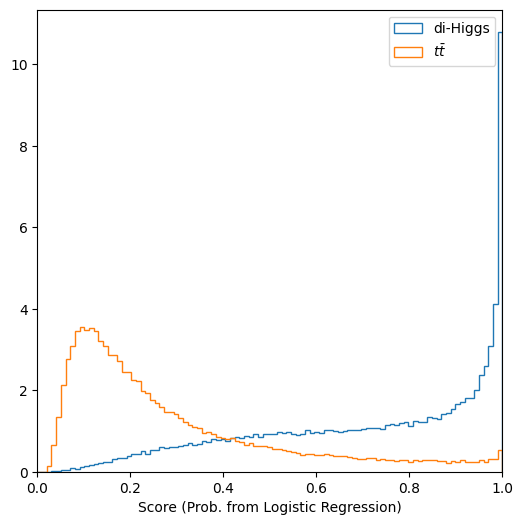

In [ ]:
plt.figure(figsize=(6, 6))
hist_sig = plt.hist(test_score_sig, label=r"di-Higgs", histtype="step", bins=np.linspace(0, 1, 100), density=True)
hist_bkg = plt.hist(test_score_bkg, label=r"$t\bar{t}$", histtype="step", bins=np.linspace(0, 1, 100), density=True)
plt.xlabel("Score (Prob. from Logistic Regression)")
plt.legend()
plt.xlim(0, 1)

## ROC curve and AUC

How do we measure how well the model separates signal from background? Let's do a thought experiment: if we apply any monotonic transformation to the score, for example $x \mapsto x^2$, the ability to separate signal and background does not change. For a given cut at $x > x_0$, we can simply cut at $x_0^2$ in the new score to keep the same number of signal and background events. So, we need a metric that does not depend on the exact shape of the score distribution.

Generally, for a classification problem, we usually set a threshold on the model's score to decide if an event is classified as signal or background. Based on this threshold, we can define two important quantities: the **True Positive Rate (TPR)**, which is the fraction of signal events correctly identified as signal, and the **False Positive Rate (FPR)**, which is the fraction of background events incorrectly identified as signal.

Choosing the threshold is always a trade-off: if the threshold is too low, the **FPR** increases; if the threshold is too high, the **TPR** decreases.

To evaluate a classification model, we often use the **Receiver Operating Characteristic (ROC) curve**. This curve is constructed as follows:
 1. For each threshold $x_0$, calculate the corresponding **TPR** and **FPR**.
 2. By varying $x_0$ from 0 to 1, we can plot the pairs (**TPR**, **FPR**) to form the ROC curve.

See the animation below to understand how the ROC curve is created.

<img src="figures/roc-animation-update.gif" alt="Drawing" width=900/>

scikit-learn provides built-in functions that make it easy to plot the **ROC** curve.

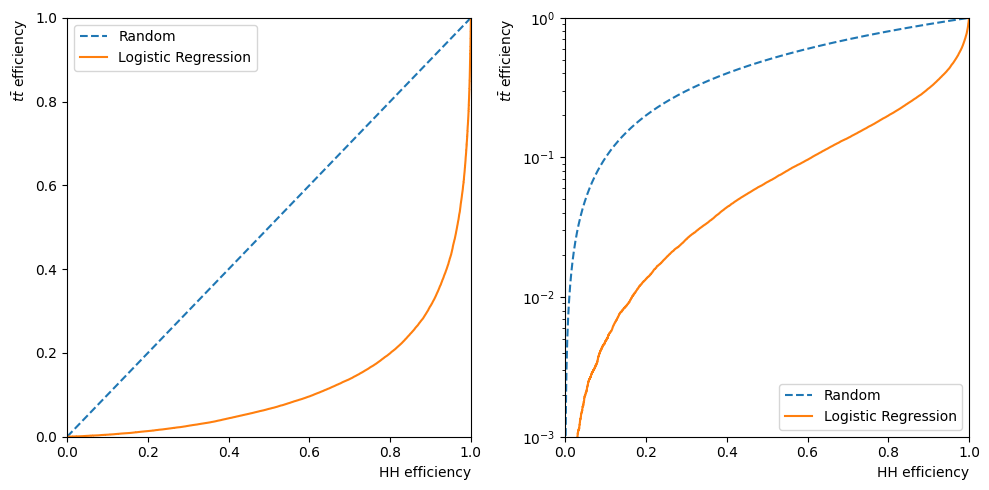

In [ ]:
import sklearn.metrics as m

# Compute the ROC curve for the classifier
# fpr_clf: False Positive Rate (background efficiency)
# tpr_clf: True Positive Rate (signal efficiency)
# _thres: thresholds used to compute the ROC
fpr_clf, tpr_clf, _thres = m.roc_curve(y_test['is_sig'], test_score[:,1])

# Create a figure with two subplots: one linear, one log scale
f = plt.figure(figsize=(10, 5), tight_layout=True)
ax1 = f.add_subplot(1, 2, 1)
ax2 = f.add_subplot(1, 2, 2)

# Loop over axes to plot ROC curve in both linear and log y-scale
for ax, ax_type in zip([ax1, ax2], ['linear', 'log']):
    ax.cla()
    # Plot the "random" classifier line (diagonal)
    ax.plot(np.linspace(0, 1, 1000), np.linspace(0, 1, 1000), '--', label='Random')
    # Plot the ROC curve for the logistic regression model
    ax.plot(tpr_clf, fpr_clf, label='Logistic Regression')
    if ax_type == 'linear':
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
    elif ax_type == 'log':
        ax.set_xlim(0, 1)
        ax.set_ylim(1e-3, 1)
        ax.set_yscale('log')
    # Set axis labels: signal efficiency (HH) vs. background efficiency (ttbar)
    ax.set_xlabel('HH efficiency', ha='right', x=1.0)
    ax.set_ylabel(r'$t\bar{t}$ efficiency', ha='right', y=1.0)
    ax.legend()

## Training a BDT model

To better separate signal from background, relying only on linear relationships between kinematic variables is not enough. We need to take a further step!

Here, we learn to use tree-based models. Gradient Boosting Decision Trees (GBDT) and XGBoost are widely used in high energy physics. They have played a crucial role in the discovery of the Higgs boson in the 2010s.

In the past (since 2007 and through the 2010s), people often used the TMVA package in ROOT, which included many BDT algorithms and even some neural network methods. In the last decade, as artificial intelligence and data science have become more popular, Python has become the main language for data science, and high energy physics has also started using Python packages for BDT training. XGBoost was introduced in 2014 and quickly became popular in the machine learning community because of its efficiency, scalability, and strong performance. It is now a standard tool in HEP analyses.

Next, we will use XGBoost as an example.

In [ ]:
# Import the XGBoost classifier
from xgboost import XGBClassifier

# Initialize the XGBoost classifier with logloss as the evaluation metric
# and fit it to the training data (X_train, y_train['is_sig'])
xgbc = XGBClassifier(eval_metric="logloss").fit(X_train, y_train['is_sig'])

In [ ]:
# Get the predicted probabilities for the test set
test_score_xgb = xgbc.predict_proba(X_test)

# Select the predicted probability for the signal class (class 1) for signal and background events
test_score_xgb_sig = test_score_xgb[y_test['is_sig']][:, 1]
test_score_xgb_bkg = test_score_xgb[y_test['is_bkg']][:, 1]

(0.0, 1.0)

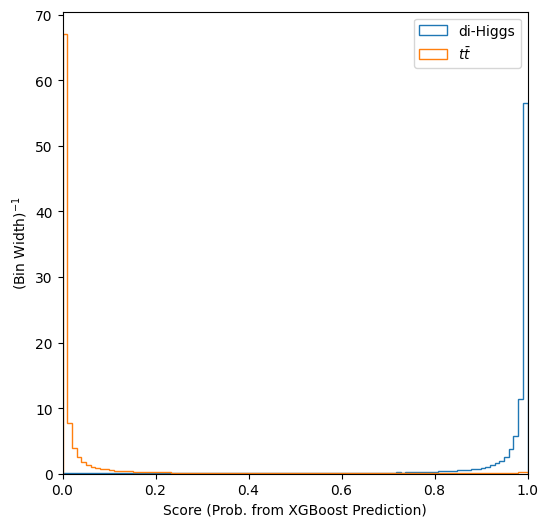

In [ ]:
# Plot the distribution of XGBoost scores for signal and background events
plt.figure(figsize=(6, 6))
hist_sig = plt.hist(test_score_xgb_sig, label=r"di-Higgs", histtype="step", bins=np.linspace(0, 1, 100), density=True)
hist_bkg = plt.hist(test_score_xgb_bkg, label=r"$t\bar{t}$", histtype="step", bins=np.linspace(0, 1, 100), density=True)
plt.xlabel("Score (Prob. from XGBoost Prediction)")
plt.ylabel("(Bin Width)$^{-1}$")
plt.legend()
plt.xlim(0, 1)

As we can see, even with the default settings, XGBoost already gives impressive classification results.

Here are some commonly used XGBoost parameters you can tune:

 1. `learning_rate`: XGBoost is a boosting algorithm. Although its optimization is not exactly the same as standard gradient-based methods, it still uses a similar idea. This parameter controls the "step size" at each iteration.
 2. Since XGBoost is a tree-based model, parameters related to the tree structure are important, such as the maximum tree depth (`max_depth`) or the number of leaf nodes (`max_leaf_nodes`). Generally, smaller values help prevent overfitting, but if they are too small, the model may not be powerful enough.
 3. There are also other parameters related to the loss function and training process. You can find more details in the [official documentation](https://xgboost.readthedocs.io/en/stable/).

Next, let's plot the ROC curve:

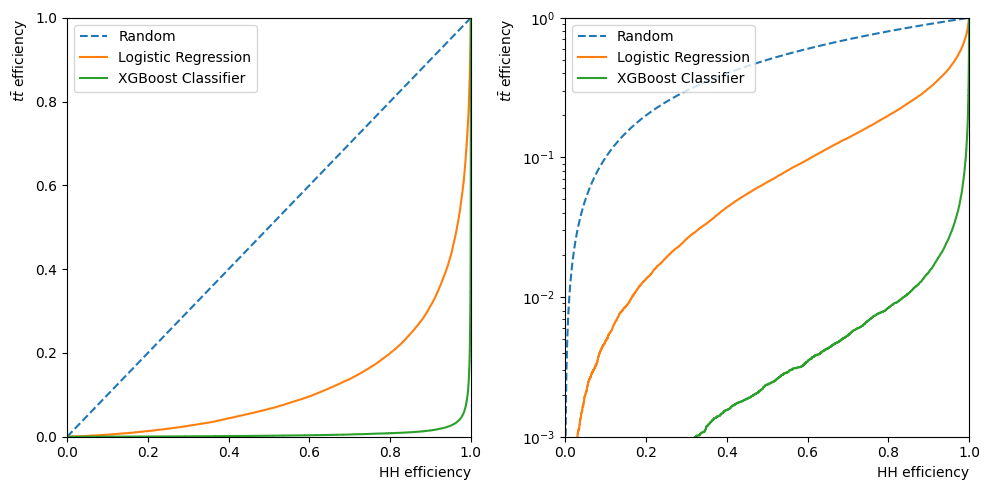

In [ ]:
import sklearn.metrics as m
fpr_xgb, tpr_xgb, _thres = m.roc_curve(y_test['is_sig'], test_score_xgb[:,1])

f = plt.figure(figsize=(10, 5), tight_layout=True)
ax1 = f.add_subplot(1, 2, 1)
ax2 = f.add_subplot(1, 2, 2)

# Loop over axes to plot ROC curve in both linear and log y-scale
for ax, ax_type in zip([ax1, ax2], ['linear', 'log']):
    ax.cla()
    ax.plot(np.linspace(0, 1, 1000), np.linspace(0, 1, 1000), '--', label='Random')
    ax.plot(tpr_clf, fpr_clf, label='Logistic Regression')
    ax.plot(tpr_xgb, fpr_xgb, label='XGBoost Classifier')
    if ax_type == 'linear':
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
    elif ax_type == 'log':
        ax.set_xlim(0, 1)
        ax.set_ylim(1e-3, 1)
        ax.set_yscale('log')
    ax.set_xlabel('HH efficiency', ha='right', x=1.0)
    ax.set_ylabel(r'$t\bar{t}$ efficiency', ha='right', y=1.0)
    ax.legend()


> XGBoost (like other BDT models) shows its strong performance!

Let's then try to understand what XGBoost has learned. We want to check which input features are most important for the classification.

XGBoost provides a function called `plot_importance` that can show how important each feature is for the model.

<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

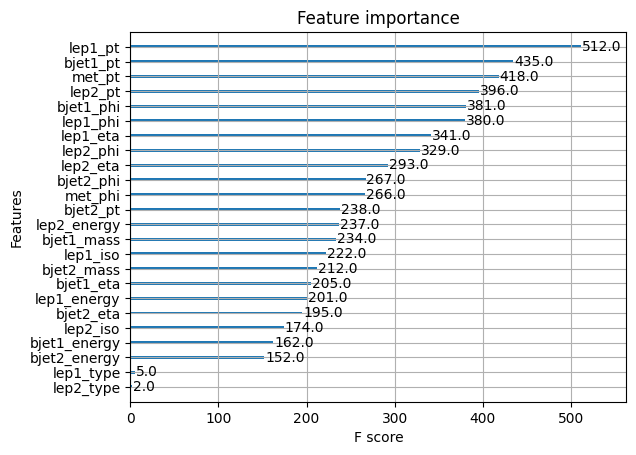

In [ ]:
from xgboost import plot_importance
plot_importance(xgbc)

> XGBoost supports several ways to measure feature importance, such as weight, gain, cover, total_cover, and total_gain. These metrics reflect feature importance from different perspectives.

> The F-score is a common metric used in decision tree models to measure how important a feature (in our case, a kinematic variable) is. It counts how many times a feature is used to split the data during the classification process.

Finally, let's save the ROC curve data for later use.

In [ ]:
os.makedirs('data', exist_ok=True)
np.savetxt("data/roc_lr.dat", [tpr_clf, fpr_clf])
np.savetxt("data/roc_xgb.dat", [tpr_xgb, fpr_xgb])

### Exercise 1a
- What is the default `learning_rate` and `max_leaf_nodes` used in the above training?
- Train the BDT again with `learning_rate = 0.05` OR `max_leaf_nodes = 10`, and compare the ROC curve results.

## Training a DNN model

Now let's switch to using a deep neural network (DNN) model!

Neural networks have been around since the 1980s, when they were called artificial neural networks (ANNs). However, it wasn't until around 2012, when hardware became powerful enough, that deep neural networks became popular again. Since then, people have been able to train large and deep networks, and deep learning has achieved great success, especially in image classification competitions like ImageNet. This marked the beginning of the deep learning era.

To get an intuitive understanding of how neural networks work, we highly recommend watching the 3Blue1Brown video series after class. The visualizations are excellent.
> https://www.bilibili.com/video/BV1bx411M7Zx/ (There are three parts)

Today, we will mainly introduce neural networks through slides.

### Introduction to PyTorch

We will use PyTorch to build our neural networks. PyTorch is an open-source machine learning framework that allows users to freely design and efficiently train their own neural networks. PyTorch is not the only deep learning framework—others include TensorFlow, JAX, and Caffe.

Today, PyTorch has a very mature ecosystem and a large developer community (it was originally developed by Facebook). It is very flexible and widely used in research. Many recent research papers release their code in PyTorch.
The figure below shows the share of PyTorch and other frameworks in research papers. You can see that PyTorch now dominates more than half of the field.

<img src="figures/percentage_repo_2023.png" alt="image" width=700/>

In general, building and training networks with PyTorch can take a bit more work—especially for beginners, who often use easier tools like Keras. But as deep learning has grown quickly in recent years, PyTorch has become very popular among researchers. That’s why we use PyTorch in this tutorial, so we can keep up with the latest trends in deep learning. In the next section (for self-reading), we will also look at more advanced models like Transformers, which are built by PyTorch as well.

In short, building a network is like building a castle out of LEGO blocks—PyTorch provides the basic building blocks, while some high-level packages only offer a few pre-built castles to choose from.

In our tutorial, we will also use pytorch-lightning on top of PyTorch. This package wraps some common PyTorch settings, making our code shorter and easier to read.

If you want to systematically learn PyTorch, you can check out the following resources:
 - PyTorch official 60-minute tutorial: https://pytorch.org/tutorials/beginner/deep_learning_60min_blitz.html
 - UvA teaching materials: https://uvadlc-notebooks.readthedocs.io/en/latest/tutorial_notebooks/tutorial2/Introduction_to_PyTorch.html

Next, let's introduce the basic elements needed to train with PyTorch:
 - Model: building a PyTorch model (`nn.Module`) is like assembling LEGO blocks. You use basic nn.BlaBla blocks to build the model you want. In the `__init__` method, you set up the building blocks, and in the `forward` method, you define how data flows through the network. For a simple neural network, you can define several nn.Linear layers, and in the forward method, connect them in the order: Linear layer -> ReLU activation -> Linear layer -> ReLU activation -> Linear layer.
 - Dataset: our dataset is the same as in the previous example, but we need to load it using PyTorch's dataset format. In this class, we define the total number of samples (`__len__`) and a `__getitem__` function to get the item at a specific index.

For example, below is a simple `nn.Module`! Try to understand what it does.

In [ ]:
import torch

# Define a simple neural network model using PyTorch
class TinyModel(torch.nn.Module):

    def __init__(self):
        super(TinyModel, self).__init__()
        self.linear1 = torch.nn.Linear(100, 200)  # First linear layer: input size 100, output size 200
        self.activation = torch.nn.ReLU()         # ReLU activation function
        self.linear2 = torch.nn.Linear(200, 10)   # Second linear layer: input size 200, output size 10
        self.softmax = torch.nn.Softmax()         # Softmax activation for output layer (for multi-class classification)

    def forward(self, x):
        x = self.linear1(x)                       # Pass input through first linear layer
        x = self.activation(x)                    # Apply ReLU activation
        x = self.linear2(x)                       # Pass through second linear layer
        x = self.softmax(x)                       # Apply softmax to get class probabilities
        return x

# Instantiate the model
tinymodel = TinyModel()

# Print the full model architecture
print('The model:')
print(tinymodel)

# Print only the second linear layer
print('\n\nJust one layer:')
print(tinymodel.linear2)

# Print all parameters of the model
print('\n\nModel params:')
for param in tinymodel.parameters():
    print(param)

# Print parameters of the second linear layer only
print('\n\nLayer params:')
for param in tinymodel.linear2.parameters():
    print(param)

The model:
TinyModel(
  (linear1): Linear(in_features=100, out_features=200, bias=True)
  (activation): ReLU()
  (linear2): Linear(in_features=200, out_features=10, bias=True)
  (softmax): Softmax(dim=None)
)


Just one layer:
Linear(in_features=200, out_features=10, bias=True)


Model params:
Parameter containing:
tensor([[ 0.0202, -0.0885, -0.0060,  ...,  0.0506,  0.0435,  0.0855],
        [ 0.0197, -0.0156, -0.0240,  ..., -0.0419,  0.0574,  0.0730],
        [-0.0065,  0.0179,  0.0895,  ..., -0.0997,  0.0470,  0.0239],
        ...,
        [ 0.0151,  0.0367,  0.0276,  ...,  0.0371, -0.0784, -0.0046],
        [ 0.0358,  0.0170, -0.0785,  ..., -0.0859, -0.0267,  0.0274],
        [-0.0427, -0.0360,  0.0398,  ..., -0.0452,  0.0421,  0.0932]],
       requires_grad=True)
Parameter containing:
tensor([-0.0746, -0.0741, -0.0207,  0.0473, -0.0731, -0.0012, -0.0734, -0.0496,
        -0.0515, -0.0955,  0.0530, -0.0325,  0.0749, -0.0962,  0.0056,  0.0767,
        -0.0015, -0.0375,  0.0010, -0.04

### Start training

We will build a simple neural network to perform a basic binary classification task.

<img src="figures/dnn-visualize.png" alt="image" width=900/>

Next, let's define our PyTorch model and set up the PyTorch Lightning Trainer:

In [ ]:
## Install the lightning package if using SWAN/lxplus-gpu for the first time
## (uncomment and run the lines below)

# !pip install lightning --user

# import os, sys
# sys.path.append(f"{os.environ['HOME']}/.local/lib/python3.13/site-packages")

In [ ]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import lightning as L
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from torch import nn
import torchmetrics

# Define the PyTorch Lightning model for a simple multilayer perceptron (MLP)
class SimpleMLP(L.LightningModule):
    def __init__(self, input_size, hidden_size, output_size):
        super(SimpleMLP, self).__init__()
        self.layer1 = nn.Linear(input_size, hidden_size)   # First fully connected layer
        self.layer2 = nn.Linear(hidden_size, hidden_size)  # Second fully connected layer
        self.layer3 = nn.Linear(hidden_size, output_size)  # Output layer

        self.train_acc = torchmetrics.Accuracy(task="multiclass", num_classes=output_size)  # Accuracy metrics for training
        self.val_acc = torchmetrics.Accuracy(task="multiclass", num_classes=output_size)    # Accuracy metrics for validation

    def forward(self, x):
        # Forward pass: input -> relu -> hidden -> relu -> output
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        x = self.layer3(x)
        return x

    def training_step(self, batch, batch_idx):
        # Defines the operations for each training batch
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        self.train_acc(logits, y)
        # Log training loss and accuracy
        self.log('train_loss', loss)
        self.log('train_acc', self.train_acc, on_step=False, on_epoch=True)
        # Log current learning rate
        self.log('lr', self.trainer.optimizers[0].param_groups[0]['lr'])
        return loss

    def validation_step(self, batch, batch_idx):
        # Defines the operations for each validation batch
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        self.val_acc(logits, y)
        # Log validation loss and accuracy
        self.log('val_loss', loss)
        self.log('val_acc', self.val_acc, on_step=False, on_epoch=True)
        return loss

    def configure_optimizers(self):
        # Set up optimizer and learning rate scheduler
        optimizer = torch.optim.Adam(self.parameters(), lr=0.01)
        
        # Learning rate schedule: constant for 70% of epochs, then exponential decay to 1% of initial value
        def lr_lambda(epoch):
            if epoch < 0.7 * self.trainer.max_epochs:
                return 1.0
            else:
                decay_factor = (epoch - 0.7 * self.trainer.max_epochs) / (0.3 * self.trainer.max_epochs)
                return 0.01 ** decay_factor

        scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
        return [optimizer], [scheduler]


# Define a custom PyTorch Dataset to wrap a pandas DataFrame
# See: https://pytorch.org/tutorials/beginner/basics/data_tutorial.html
class DataFrameDataset(Dataset):
    def __init__(self, dataframe, input_columns, target_column):
        # Store the dataframe and extract input features and targets
        self.dataframe = dataframe
        self.inputs = dataframe[input_columns].values
        self.targets = dataframe[target_column].values.astype(np.int64)

    def __len__(self):
        # Return the number of samples in the dataset
        return len(self.dataframe)

    def __getitem__(self, idx):
        # Retrieve the input features and label for a given index
        x = torch.tensor(self.inputs[idx], dtype=torch.float32)  # N-dimensional input features
        y = torch.tensor(self.targets[idx], dtype=torch.long)    # 1-dimensional label
        return x, y

After defining the PyTorch Model and Dataset classes, we need to initialize them.

Everything starts from the pandas DataFrame, which holds our data and is used as input for the PyTorch Dataset. With the Dataset, we use PyTorch's built-in DataLoader to sample data. Here, we set the `batch_size`, which means how many samples are in each batch during training. The DataLoader will group the data into multi-dimensional tensors, where the first dimension is the `batch_size`, so the model processes the data batch by batch.

In [ ]:
input_columns = ['bjet1_pt_trans', 'bjet1_eta_trans', 'bjet1_phi_trans', 'bjet1_energy_trans', 'bjet1_mass_trans',
       'bjet2_pt_trans', 'bjet2_eta_trans', 'bjet2_phi_trans', 'bjet2_energy_trans', 'bjet2_mass_trans',
       'lep1_pt_trans', 'lep1_eta_trans', 'lep1_phi_trans', 'lep1_energy_trans', 'lep1_type', 'lep1_iso',
       'lep2_pt_trans', 'lep2_eta_trans', 'lep2_phi_trans', 'lep2_energy_trans', 'lep2_type', 'lep2_iso',
       'met_pt_trans', 'met_phi_trans']
target_column = 'is_sig'

# Split the data into training/validation/testing datasets following 80/10/10%
train_df, test_df = train_test_split(df, test_size=0.2)
val_df, test_df = train_test_split(test_df, test_size=0.5)

# Create datasets
train_dataset = DataFrameDataset(train_df, input_columns, target_column)
val_dataset = DataFrameDataset(val_df, input_columns, target_column)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=1024, num_workers=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1024, num_workers=4)

# Create Model instance (24 kinematic inputs)
model_mlp = SimpleMLP(input_size=24, hidden_size=64, output_size=2)

In [ ]:
# Trainer with a logger (you may change the name here!)
trainer = L.Trainer(max_epochs=20, logger=L.pytorch.loggers.TensorBoardLogger('tb_logs', name='simple_mlp'))

# Fit the model
trainer.fit(model_mlp, train_loader, val_loader)

### Monitoring training with TensorBoard

TensorBoard is a useful tool for monitoring training and checking metrics. If you have used Jupyter before, TensorBoard works in a similar way: you start a TensorBoard service and then open it in your browser at a specific port.

In a notebook, if you are working on local machine, you can start TensorBoard with the following magic command:

In [ ]:
# Load the tensorboard extension
%load_ext tensorboard

In [ ]:
# Start the tensorboard service (monitoring the "tb_logs" directory)
%tensorboard --logdir tb_logs

However, this does not work on SWAN, so you can launch the service manually. The procedure is the same as described in the [repository's README](https://gitlab.cern.ch/das-hefei2026/exercise/-/tree/master/Short_exercise/Machine_Learning?ref_type=heads) -- simply replace the `jupyter lab ...` command with:

```bash
tensorboard --logdir tb_logs
```

Take note of the port number (typically 6006). Then forward the port to your local machine, and open TensorBoard in your browser at: http://localhost:6006

You will see a panel like the one below.

Pay attention to the "scalars" tab on the left. Here, you can observe how the model's accuracy and loss on the training and validation sets change during training.

 - As the network trains and gets optimized, **the accuracy should increase and the loss should decrease.**
 - The curves for the training and validation sets should be very similar. If the training curve is much better than the validation curve, it means the model is overfitting.

<img src="figures/tensorboard-output-updated.png" alt="image" width=900/>

### Performance evaluation

Let's use the trained model to perform inference on the test dataset and obtain the output results!

In a standard neural network training workflow, the dataset is typically split into three parts: the training dataset, the validation dataset, and the test dataset. Here, we use the test dataset to evaluate the model's performance.

In [ ]:
# This is a dataset class for inference (predicting scores).
# It returns only the input features, without the label.
# Compare this with the DataFrameDataset used for training/validation, which also returns the label.
class DataFrameDatasetForInference(Dataset):
    def __init__(self, dataframe, input_columns):
        self.inputs = dataframe[input_columns].values

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        x = torch.tensor(self.inputs[idx], dtype=torch.float32)
        return x

test_dataset = DataFrameDatasetForInference(test_df, input_columns)
test_loader = DataLoader(test_dataset, batch_size=1024, shuffle=False)

# If your model is saved, load it
# model_mlp = SimpleMLP.load_from_checkpoint('path_to_checkpoint.ckpt')

# Use the trainer to predict
predictions_mlp = trainer.predict(model_mlp, dataloaders=test_loader)

# Flatten list of tensors
predictions_mlp = [p.numpy() for batch in predictions_mlp for p in batch]

The predictions here are the two logits produced by the last layer of the network. When we use `F.cross_entropy` to calculate the loss, it automatically applies softmax to the logits. Therefore, our logits are not normalized yet, and we need to manually apply softmax to obtain probabilities.

> Please make sure you understand why this step is needed.

In [ ]:
test_score = np.array([np.exp(p[1]) / (np.exp(p[0]) + np.exp(p[1])) for p in predictions_mlp])

Now we can plot the distribution of the scores. Compare the results with the previous section to see if the separation between signal and background has improved. Also, plot the ROC curve to compare all the models we have used so far.

(0.0, 1.0)

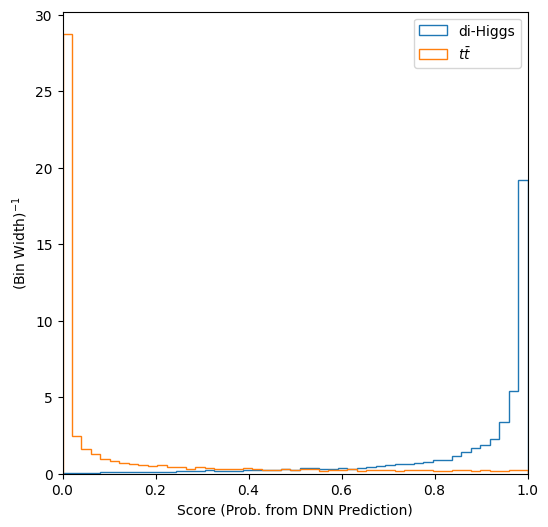

In [ ]:
plt.figure(figsize=(6, 6))
hist_sig = plt.hist(test_score[test_df['is_sig']], label=r"di-Higgs", histtype="step", bins=np.linspace(0,1), density=True)
hist_bkg = plt.hist(test_score[test_df['is_bkg']], label=r"$t\bar{t}$", histtype="step", bins=np.linspace(0,1), density=True)
plt.xlabel("Score (Prob. from DNN Prediction)")
plt.ylabel("(Bin Width)$^{-1}$")
plt.legend()
plt.xlim(0,1)

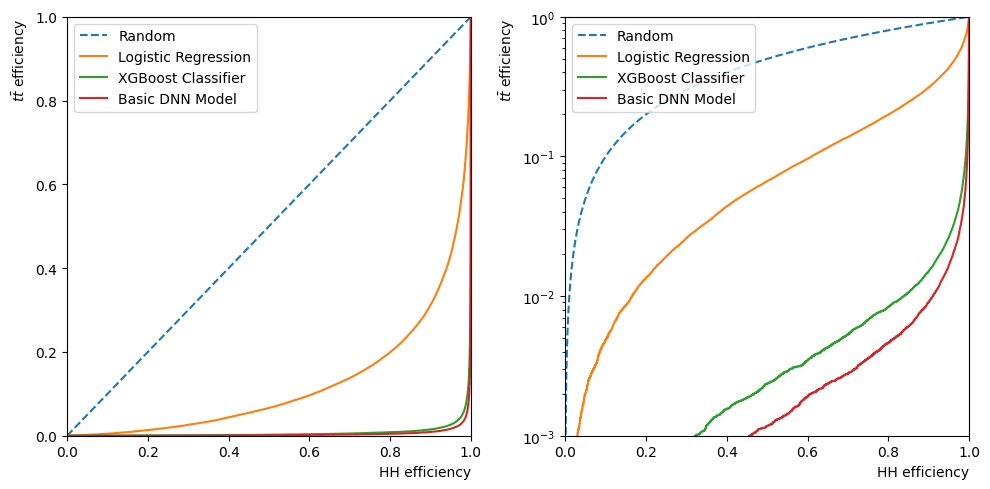

In [ ]:
# Draw the ROC curve

import sklearn.metrics as m
fpr, tpr, _thres = m.roc_curve(test_df['is_sig'], test_score)

import matplotlib.pyplot as plt
import matplotlib as mpl
import mplhep as hep

# Create a figure with two subplots: one linear, one log scale
f = plt.figure(figsize=(10, 5), tight_layout=True)
ax1 = f.add_subplot(1, 2, 1)
ax2 = f.add_subplot(1, 2, 2)

# Loop over axes to plot ROC curve in both linear and log y-scale
for ax, ax_type in zip([ax1, ax2], ['linear', 'log']):

    ## the random guess line
    ax.plot(np.linspace(0, 1, 1000), np.linspace(0, 1, 1000), '--', label='Random')
    
    ## first include the ROC curves from the previous ML tasks
    tpr_clf, fpr_clf = np.loadtxt("data/roc_lr.dat")
    tpr_xgb, fpr_xgb = np.loadtxt("data/roc_xgb.dat")
    ax.plot(tpr_clf, fpr_clf, label='Logistic Regression')
    ax.plot(tpr_xgb, fpr_xgb, label='XGBoost Classifier')

    # then plot the ROC curve of the current DNN model
    ax.plot(tpr, fpr, label='Basic DNN Model')

    if ax_type == 'linear':
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
    elif ax_type == 'log':
        ax.set_xlim(0, 1)
        ax.set_ylim(1e-3, 1)
        ax.set_yscale('log')
    ax.set_xlabel('HH efficiency', ha='right', x=1.0)
    ax.set_ylabel(r'$t\bar{t}$ efficiency', ha='right', y=1.0)
    ax.legend()

plt.show()

We can see that in this simple example, the DNN model performs better than the BDT.

This is also generally true in real experiments. For example, in CMS, neural networks are now used more often than traditional BDT methods in physics analyses.

In [ ]:
## Save the ROC curve data
os.makedirs('data', exist_ok=True)
np.savetxt("data/roc_dnn.dat", [tpr, fpr])

#### Exercise 1b

 - Play with the network configuration. What will happen if you 

    (1) Change the number of epochs to 40? 

    (2) Change the number of epochs to 40, and the learning rate to 0.005 (2× smaller)?

    (3) Enlarge the hidden-layer dimension to 256?

Compare the TensorBoard metrics and the resulting ROC curves of all these trainings (see `hw.md` for example).